# ECON 422: Macroeconomics & Machine Learning
## SHapley Additive exPlanations (SHAP)

$$
\boxed{
\text{Shapley value}
\longrightarrow
\text{LMG with }v(S)=R^2(S)
\longrightarrow
\text{SHAP with }v_x(S)
}
$$

**Main idea:** average marginal contribution across all possible orderings.

### Practice 1 — Install the required packages

**What this code does.** This cell installs the two external packages used below: `pyshapley2` for the LMG decomposition and `shap` for prediction explanations.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;font-family:Menlo,Monaco,Consolas,'Courier New',monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;"># Install the two packages used for LMG and SHAP.
%pip install -q pyshapley2 shap</pre>

In [1]:
# Type the code here.
%pip install -q pyshapley2 shap

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


### Practice 2 — Import the packages

**What this code does.** This cell loads the tools used throughout the notebook: permutations for feature orderings, pandas/numpy for data work, scikit-learn for the random forest, and the LMG/SHAP packages.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;font-family:Menlo,Monaco,Consolas,'Courier New',monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;"># Generate all possible feature orderings.
from itertools import permutations

# Standard data and plotting tools.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# SHAP package for prediction explanations.
import shap

# pyshapley2 computes the LMG/Shapley decomposition of R-squared.
from pyshapley2 import shapley2

# Random forest and estimation/testing split.
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split</pre>

In [2]:
# Type the code here.
from itertools import permutations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# SHAP package for prediction explanations.
import shap

# pyshapley2 computes the LMG/Shapley decomposition of R-squared.
from pyshapley2 import shapley2

# Random forest and estimation/testing split.
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


c:\Users\mbadi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Shapley value

For player $i$, given predecessor coalition $S$,

$$
v(S\cup\{i\})-v(S)
$$

is the marginal contribution of $i$. Ordering matters because it determines $S$.

### Practice 3 — Two-player ordering example

**What this code does.** This cell reproduces the Shapley idea directly for two players. It computes each player's incremental contribution under both possible orderings and then averages across orderings.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;font-family:Menlo,Monaco,Consolas,'Courier New',monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;"># Define the value v(S) for every possible coalition.
# frozenset is used because dictionary keys must be immutable.
game = {
    frozenset(): 0,                  # v(empty set)
    frozenset([&quot;A&quot;]): 4,             # v({A})
    frozenset([&quot;B&quot;]): 3,             # v({B})
    frozenset([&quot;A&quot;, &quot;B&quot;]): 5         # v({A,B})
}

rows = []                            # Store one result row per ordering

# With two players, the possible orderings are A -&gt; B and B -&gt; A.
for order in permutations([&quot;A&quot;, &quot;B&quot;]):

    S = set()                        # Start from the empty coalition
    before = game[frozenset(S)]      # Value before the next player enters
    row = {&quot;ordering&quot;: &quot; -&gt; &quot;.join(order)}

    # Add players one at a time following this ordering.
    for player in order:
        S.add(player)                                # Add the next player
        after = game[frozenset(S)]                   # Coalition value after entry
        row[player] = after - before                 # Marginal contribution
        before = after                               # Update for the next player

    row[&quot;row sum&quot;] = before - game[frozenset()]      # Total value created
    rows.append(row)

# Rows = orderings; columns = contributions assigned to A and B.
table = pd.DataFrame(rows).set_index(&quot;ordering&quot;)

display(table)

# Average each player&#x27;s contribution across all orderings = Shapley value.
display(
    table[[&quot;A&quot;, &quot;B&quot;]]
    .mean()
    .rename(&quot;Shapley value&quot;)
    .to_frame()
)</pre>

In [4]:
# Type the code here.
# Define the value v(S) for every possible coalition.
# frozenset is used because dictionary keys must be immutable.
game = {
    frozenset(): 0,                  # v(empty set)
    frozenset(["A"]): 4,             # v({A})
    frozenset(["B"]): 3,             # v({B})
    frozenset(["A", "B"]): 5         # v({A,B})
}

rows = []                            # Store one result row per ordering

# With two players, the possible orderings are A -&gt; B and B -&gt; A.
for order in permutations(["A", "B"]):

    S = set()                        # Start from the empty coalition
    before = game[frozenset(S)]      # Value before the next player enters
    row = {"ordering": " -> ".join(order)}

    # Add players one at a time following this ordering.
    for player in order:
        S.add(player)                                # Add the next player
        after = game[frozenset(S)]                   # Coalition value after entry
        row[player] = after - before                 # Marginal contribution
        before = after                               # Update for the next player

    row["row sum"] = before - game[frozenset()]      # Total value created
    rows.append(row)

# Rows = orderings; columns = contributions assigned to A and B.
table = pd.DataFrame(rows).set_index("ordering")

display(table)

# Average each player's contribution across all orderings = Shapley value.
display(
    table[["A", "B"]]
    .mean()
    .rename("Shapley value")
    .to_frame()
)

,A,B,row sum
ordering,,,
A -> B,4,1,5
B -> A,2,3,5


,Shapley value
A,3.0
B,2.0


## 2. LMG

LMG is the Shapley decomposition with

$$
v(S)=R^2(S).
$$

So each predictor receives its average incremental contribution to explanatory fit.

### Practice 4 — Compute LMG with `pyshapley2`

**What this code does.** This cell creates a small regression example and lets `pyshapley2` compute the LMG shares of the full model's $R^2$.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;font-family:Menlo,Monaco,Consolas,'Courier New',monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;"># Fix the random seed so everyone gets the same numerical results.
rng_lmg = np.random.default_rng(422)
n_lmg = 300

# Generate three predictors.
df_lmg = pd.DataFrame({
    &quot;X1&quot;: rng_lmg.normal(size=n_lmg),
    &quot;X2&quot;: rng_lmg.normal(size=n_lmg),
    &quot;X3&quot;: rng_lmg.normal(size=n_lmg)
})

# Make X2 partly related to X1 so predictors share explanatory information.
df_lmg[&quot;X2&quot;] += 0.40 * df_lmg[&quot;X1&quot;]

# Simulated regression outcome.
df_lmg[&quot;y&quot;] = (
    1.0
    + 1.2 * df_lmg[&quot;X1&quot;]
    + 0.8 * df_lmg[&quot;X2&quot;]
    + 0.4 * df_lmg[&quot;X3&quot;]
    + rng_lmg.normal(scale=1.0, size=n_lmg)
)

# Compute the Shapley/LMG decomposition of model R-squared.
lmg_result = shapley2(
    df_lmg,
    depvar=&quot;y&quot;,                      # Outcome variable
    indepvars=[&quot;X1&quot;, &quot;X2&quot;, &quot;X3&quot;],    # Predictors whose R-squared shares we want
    stat=&quot;r2&quot;                        # Decompose R-squared
)

# Stata-style summary of the decomposition.
lmg_result.summary()

# Numeric LMG contributions for each predictor.
display(lmg_result.table)

# The contributions together correspond to the full model&#x27;s R-squared.
print(&quot;Full-model R-squared:&quot;, round(lmg_result.full_stat, 4))</pre>

In [5]:
# Type the code here.
# Fix the random seed so everyone gets the same numerical results.
rng_lmg = np.random.default_rng(422)
n_lmg = 300

# Generate three predictors.
df_lmg = pd.DataFrame({
    "X1": rng_lmg.normal(size=n_lmg),
    "X2": rng_lmg.normal(size=n_lmg),
    "X3": rng_lmg.normal(size=n_lmg)
})

# Make X2 partly related to X1 so predictors share explanatory information.
df_lmg["X2"] += 0.40 * df_lmg["X1"]

# Simulated regression outcome.
df_lmg["y"] = (
    1.0
    + 1.2 * df_lmg["X1"]
    + 0.8 * df_lmg["X2"]
    + 0.4 * df_lmg["X3"]
    + rng_lmg.normal(scale=1.0, size=n_lmg)
)

# Compute the Shapley/LMG decomposition of model R-squared.
lmg_result = shapley2(
    df_lmg,
    depvar="y",                      # Outcome variable
    indepvars=["X1", "X2", "X3"],    # Predictors whose R-squared shares we want
    stat="r2"                        # Decompose R-squared
)

# Stata-style summary of the decomposition.
lmg_result.summary()

# Numeric LMG contributions for each predictor.
display(lmg_result.table)

# The contributions together correspond to the full model&#x27;s R-squared.
print("Full-model R-squared:", round(lmg_result.full_stat, 4))

Shapley-Owen decomposition  |  depvar: y  |  stat: r2  |  command: ols
Observations: 300  |  Subsets: 8  |  K=3

Factor     │ Shapley value │ Per cent  │Shapley value │  Per cent   
           │  (estimate)   │(estimate) │ (normalized) │(normalized) 
───────────┼───────────────┼───────────┼──────────────┼─────────────
X1         │       0.43620 │    59.09 % │      0.43669 │      59.15 %
X2         │       0.26697 │    36.16 % │      0.26726 │      36.20 %
X3         │       0.03424 │     4.64 % │      0.03428 │       4.64 %
───────────┼───────────────┼───────────┼──────────────┼─────────────
Residual   │       0.00081 │     0.11 % │              │             
───────────┼───────────────┼───────────┼──────────────┼─────────────
TOTAL      │       0.73823 │   100.00 % │      0.73823 │     100.00 %
───────────┼───────────────┼───────────┼──────────────┼─────────────


,shapley,shapley_pct,shapley_norm,shapley_norm_pct
X1,0.436204,59.088183,0.436685,59.153329
X2,0.266965,36.163081,0.267260,36.202952
X3,0.034243,4.638606,0.034281,4.643720


Full-model R-squared: 0.7382


## 3. SHAP

For one observation $x$, SHAP replaces $R^2(S)$ with a prediction value $v_x(S)$.

The full coalition is $N=\{A,B,C\}$, not the ordering $ABC$. Every ordering reaches
the same full prediction; only the allocation across features changes.

### Practice 5 — Fit a random forest

**What this code does.** This cell creates a simulated macro dataset, splits it into estimation and testing samples, and fits the random forest whose predictions we will explain.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;font-family:Menlo,Monaco,Consolas,'Courier New',monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;"># Fix the seed so the example is reproducible.
rng = np.random.default_rng(422)
n = 300

# Generate the three macro predictors used in the SHAP example.
X = pd.DataFrame({
    &quot;inflation&quot;: rng.normal(size=n),
    &quot;unemployment&quot;: rng.normal(size=n),
    &quot;interest_rate&quot;: rng.normal(size=n)
})

# Create some correlation between inflation and unemployment.
X[&quot;unemployment&quot;] += 0.35 * X[&quot;inflation&quot;]

# Simulated outcome y.
# Think of y as a generic macro outcome such as output growth.
y = (
    2.0
    + 0.9 * X[&quot;inflation&quot;]
    - 1.1 * X[&quot;unemployment&quot;]
    - 0.8 * X[&quot;interest_rate&quot;]
    + 0.7 * X[&quot;inflation&quot;] * X[&quot;unemployment&quot;]   # Nonlinear interaction
    + rng.normal(scale=0.7, size=n)
)

# Split the data into estimation and testing samples.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=422
)

# Fit a random forest on the estimation sample.
model = RandomForestRegressor(
    n_estimators=150,                # Number of trees
    min_samples_leaf=5,              # Minimum observations in each terminal leaf
    random_state=422,
    n_jobs=-1                        # Use all available CPU cores
).fit(X_train, y_train)

# Out-of-sample predictive fit on the testing sample.
print(&quot;Test R-squared:&quot;, round(model.score(X_test, y_test), 3))</pre>

In [6]:
# Type the code here.
# Fix the seed so the example is reproducible.
rng = np.random.default_rng(422)
n = 300

# Generate the three macro predictors used in the SHAP example.
X = pd.DataFrame({
    "inflation": rng.normal(size=n),
    "unemployment": rng.normal(size=n),
    "interest_rate": rng.normal(size=n)
})

# Create some correlation between inflation and unemployment.
X["unemployment"] += 0.35 * X["inflation"]

# Simulated outcome y.
# Think of y as a generic macro outcome such as output growth.
y = (
    2.0
    + 0.9 * X["inflation"]
    - 1.1 * X["unemployment"]
    - 0.8 * X["interest_rate"]
    + 0.7 * X["inflation"] * X["unemployment"]   # Nonlinear interaction
    + rng.normal(scale=0.7, size=n)
)

# Split the data into estimation and testing samples.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=422
)

# Fit a random forest on the estimation sample.
model = RandomForestRegressor(
    n_estimators=150,                # Number of trees
    min_samples_leaf=5,              # Minimum observations in each terminal leaf
    random_state=422,
    n_jobs=-1                        # Use all available CPU cores
).fit(X_train, y_train)

# Out-of-sample predictive fit on the testing sample.
print("Test R-squared:", round(model.score(X_test, y_test), 3))

Test R-squared: 0.726


### Note on $v_x(S)$

In this manual illustration, $S$ tells us **which features from the observation being explained are currently allowed to enter the prediction**.

For the first test observation $x$:

- if $S=\varnothing$, none of $x$'s actual feature values are used, so all features stay at their estimation-sample means;
- if $S=\{\text{inflation}\}$, the model uses this observation's actual inflation value, while unemployment and the interest rate stay at their mean values;
- if $S=\{\text{inflation},\text{unemployment}\}$, both actual values are used and only the interest rate remains at its mean;
- once all three features are in $S$, $v_x(S)$ equals the full fitted prediction $\widehat f(x)$.

So $v_x(S)$ lets us add features one at a time and measure how much the prediction changes when each feature enters.

### Practice 6 — Average feature contributions over all six orderings

**What this code does.** This cell manually reproduces the SHAP logic for the first test observation: try all six feature orderings, compute each feature's incremental contribution, then average by feature.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;font-family:Menlo,Monaco,Consolas,'Courier New',monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;"># Features in the model.
names = [&quot;inflation&quot;, &quot;unemployment&quot;, &quot;interest_rate&quot;]

# First test observation: this is the observation we want to explain.
x = X_test.iloc[0]

# Baseline feature values: estimation-sample means.
reference = X_train.mean()

def v_x(S):
    # Start from the baseline values.
    row = reference.copy()

    # For features already in S, replace the baseline with this observation&#x27;s actual values.
    row.loc[list(S)] = x.loc[list(S)]

    # Return the model prediction for this mixture of actual and baseline values.
    return model.predict(pd.DataFrame([row]))[0]

rows = []                            # Store one row per feature ordering

# Loop over all 3! = 6 possible feature orderings.
for order in permutations(names):

    S = []                           # Start with no actual feature from x included
    before = v_x(S)                  # Baseline prediction for this ordering
    row = {&quot;ordering&quot;: &quot; -&gt; &quot;.join(order)}

    # Add features one at a time.
    for feature in order:
        S.append(feature)            # Add the current feature to the coalition
        after = v_x(S)               # Prediction after this feature enters
        row[feature] = after - before  # Marginal contribution of this feature
        before = after               # Update the reference prediction

    # Under every ordering, contributions add to full prediction - baseline.
    row[&quot;row sum&quot;] = sum(row[f] for f in names)
    rows.append(row)

# One row per ordering; one contribution column per feature.
shap_ordering = pd.DataFrame(rows).set_index(&quot;ordering&quot;)

# Average down each feature&#x27;s column = average marginal contribution.
phi = shap_ordering[names].mean()

# Baseline prediction: no actual values from x have entered yet.
phi0 = v_x([])

# Full prediction: all actual feature values from x are used.
fhat = v_x(names)

display(shap_ordering.round(3))
display(
    phi.rename(&quot;average marginal contribution&quot;)
       .to_frame()
       .round(3)
)

# Verify the additive decomposition.
print(&quot;Prediction gap:&quot;, round(fhat - phi0, 6))
print(&quot;Sum of average contributions:&quot;, round(phi.sum(), 6))
print(&quot;Reconstruction:&quot;, round(phi0 + phi.sum(), 6))</pre>

In [7]:
# Type the code here.
# Features in the model.
names = ["inflation", "unemployment", "interest_rate"]

# First test observation: this is the observation we want to explain.
x = X_test.iloc[0]

# Baseline feature values: estimation-sample means.
reference = X_train.mean()

def v_x(S):
    # Start from the baseline values.
    row = reference.copy()

    # For features already in S, replace the baseline with this observation&#x27;s actual values.
    row.loc[list(S)] = x.loc[list(S)]

    # Return the model prediction for this mixture of actual and baseline values.
    return model.predict(pd.DataFrame([row]))[0]

rows = []                            # Store one row per feature ordering

# Loop over all 3! = 6 possible feature orderings.
for order in permutations(names):

    S = []                           # Start with no actual feature from x included
    before = v_x(S)                  # Baseline prediction for this ordering
    row = {"ordering": " -> ".join(order)}

    # Add features one at a time.
    for feature in order:
        S.append(feature)            # Add the current feature to the coalition
        after = v_x(S)               # Prediction after this feature enters
        row[feature] = after - before  # Marginal contribution of this feature
        before = after               # Update the reference prediction

    # Under every ordering, contributions add to full prediction - baseline.
    row["row sum"] = sum(row[f] for f in names)
    rows.append(row)

# One row per ordering; one contribution column per feature.
shap_ordering = pd.DataFrame(rows).set_index("ordering")

# Average down each feature's column = average marginal contribution.
phi = shap_ordering[names].mean()

# Baseline prediction: no actual values from x have entered yet.
phi0 = v_x([])

# Full prediction: all actual feature values from x are used.
fhat = v_x(names)

display(shap_ordering.round(3))
display(
    phi.rename("average marginal contribution")
       .to_frame()
       .round(3)
)

# Verify the additive decomposition.
print("Prediction gap:", round(fhat - phi0, 6))
print("Sum of average contributions:", round(phi.sum(), 6))
print("Reconstruction:", round(phi0 + phi.sum(), 6))

,inflation,unemployment,interest_rate,row sum
ordering,,,,
inflation -> unemployment -> interest_rate,-1.592,-0.689,0.000,-2.281
inflation -> interest_rate -> unemployment,-1.592,-0.689,0.000,-2.281
unemployment -> inflation -> interest_rate,-1.560,-0.721,-0.000,-2.281
unemployment -> interest_rate -> inflation,-1.514,-0.721,-0.046,-2.281
interest_rate -> inflation -> unemployment,-1.541,-0.689,-0.051,-2.281
interest_rate -> unemployment -> inflation,-1.514,-0.716,-0.051,-2.281


,average marginal contribution
inflation,-1.552
unemployment,-0.704
interest_rate,-0.025


Prediction gap: -2.280659
Sum of average contributions: -2.280659
Reconstruction: -0.214208


Each **row** allocates the same prediction gap

$$
\widehat f(x)-v_x(\varnothing),
$$

while each **column average** is one feature's average marginal contribution. Hence,

$$
\phi_A(x)+\phi_B(x)+\phi_C(x)=\widehat f(x)-\phi_0,
\qquad
\phi_0=v_x(\varnothing).
$$

Therefore,

$$
\widehat f(x)=\phi_0+\phi_A(x)+\phi_B(x)+\phi_C(x).
$$

## 4. SHAP plots: reading the results

### Practice 7A — Compute SHAP values

**What this code does.** This cell lets the `shap` package compute the same type of feature contributions for the fitted random forest and checks that they reconstruct the prediction.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;font-family:Menlo,Monaco,Consolas,'Courier New',monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;"># Choose a background sample.
# SHAP uses it to define the reference/baseline prediction.
background = X_train.sample(50, random_state=422)

# Reset the test index so observation i = 0 is clearly the first test observation.
X_explain = X_test.reset_index(drop=True)

# Build the SHAP explainer for the fitted random forest.
explainer = shap.Explainer(model, background)

# Compute SHAP values for all test observations.
sv = explainer(X_explain)

# Explain the first observation.
i = 0

# Baseline prediction for this observation&#x27;s SHAP decomposition.
phi0 = float(np.asarray(sv[i].base_values).squeeze())

# Random-forest fitted prediction for the same observation.
prediction = model.predict(X_explain.iloc[[i]])[0]

# Local SHAP contribution of each feature for observation i = 0.
local_phi = pd.Series(
    sv[i].values,
    index=X.columns,
    name=&quot;local SHAP value&quot;
)

# The prediction gap should equal the sum of local SHAP values.
print(&quot;Baseline:&quot;, round(phi0, 3))
print(&quot;Prediction:&quot;, round(prediction, 3))
print(&quot;Prediction gap:&quot;, round(prediction - phi0, 3))
print(&quot;Sum of SHAP values:&quot;, round(local_phi.sum(), 3))

display(local_phi.to_frame().round(3))</pre>

In [8]:
# Type the code here.
# Choose a background sample.
# SHAP uses it to define the reference/baseline prediction.
background = X_train.sample(50, random_state=422)

# Reset the test index so observation i = 0 is clearly the first test observation.
X_explain = X_test.reset_index(drop=True)

# Build the SHAP explainer for the fitted random forest.
explainer = shap.Explainer(model, background)

# Compute SHAP values for all test observations.
sv = explainer(X_explain)

# Explain the first observation.
i = 0

# Baseline prediction for this observation&#x27;s SHAP decomposition.
phi0 = float(np.asarray(sv[i].base_values).squeeze())

# Random-forest fitted prediction for the same observation.
prediction = model.predict(X_explain.iloc[[i]])[0]

# Local SHAP contribution of each feature for observation i = 0.
local_phi = pd.Series(
    sv[i].values,
    index=X.columns,
    name="local SHAP value"
)

# The prediction gap should equal the sum of local SHAP values.
print("Baseline:", round(phi0, 3))
print("Prediction:", round(prediction, 3))
print("Prediction gap:", round(prediction - phi0, 3))
print("Sum of SHAP values:", round(local_phi.sum(), 3))

display(local_phi.to_frame().round(3))

Baseline: 2.132
Prediction: -0.214
Prediction gap: -2.346
Sum of SHAP values: -2.346


,local SHAP value
inflation,-1.288
unemployment,-1.111
interest_rate,0.052


### Practice 7B — Waterfall plot

**What this code does.** This cell draws a local waterfall plot for the first test observation.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;font-family:Menlo,Monaco,Consolas,'Courier New',monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;"># Waterfall plot: explain why one observation received its fitted prediction.
shap.plots.waterfall(sv[i], show=False)
plt.show()</pre>

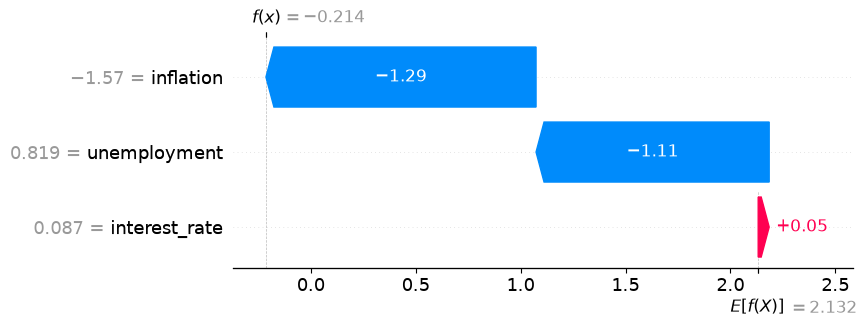

In [9]:
# Type the code here.
# Waterfall plot: explain why one observation received its fitted prediction.
shap.plots.waterfall(sv[i], show=False)
plt.show()

**How to read this result.** This plot explains the **first observation** only.

The model starts from a baseline prediction of about $2.132$. For this observation:

- inflation contributes about $-1.29$;
- unemployment contributes about $-1.11$;
- the interest rate contributes only about $+0.05$.

Together, these contributions move the prediction from about $2.132$ down to about $-0.214$.

So, in plain language: **this observation receives a low prediction mainly because inflation and unemployment push the model's prediction downward.** The interest rate offsets that only slightly.

The SHAP numbers are contributions to the **model's prediction**. They are not causal effects.

### Practice 7C — Beeswarm plot

**What this code does.** This cell draws the global beeswarm plot and computes mean absolute SHAP importance.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;font-family:Menlo,Monaco,Consolas,'Courier New',monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;"># Beeswarm plot: summarize local SHAP values across all test observations.
# Horizontal position = SHAP contribution; color = observed feature value.
shap.plots.beeswarm(sv, show=False)
plt.show()

# Global feature importance = average absolute SHAP value across observations.
importance = pd.Series(
    np.abs(sv.values).mean(axis=0),
    index=X.columns
).sort_values(ascending=False)

display(
    importance
    .rename(&quot;mean absolute SHAP&quot;)
    .to_frame()
    .round(3)
)</pre>

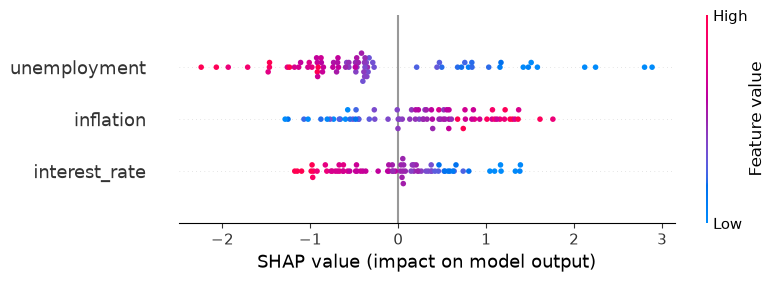

,mean absolute SHAP
unemployment,0.927
inflation,0.658
interest_rate,0.532


In [10]:
# Type the code here.
# Beeswarm plot: summarize local SHAP values across all test observations.
# Horizontal position = SHAP contribution; color = observed feature value.
shap.plots.beeswarm(sv, show=False)
plt.show()

# Global feature importance = average absolute SHAP value across observations.
importance = pd.Series(
    np.abs(sv.values).mean(axis=0),
    index=X.columns
).sort_values(ascending=False)

display(
    importance
    .rename("mean absolute SHAP")
    .to_frame()
    .round(3)
)

**How to read this result.** This plot summarizes **all test observations**.

Each dot is one observation:

- dots to the **right** mean the feature pushes the prediction upward;
- dots to the **left** mean the feature pushes the prediction downward;
- **red** means a relatively high feature value;
- **blue** means a relatively low feature value.

The mean absolute SHAP values are about:

$$
\text{unemployment}=0.927,\qquad
\text{inflation}=0.658,\qquad
\text{interest rate}=0.532.
$$

So **unemployment matters the most overall** in this fitted model.

The color pattern also gives direction. In this simulation, high unemployment values tend to appear on the negative side, so higher unemployment tends to push the model's prediction downward. High inflation values tend to push predictions upward, while high interest-rate values tend to push them downward.

These are patterns in the fitted model.

### Practice 7D — Dependence plot

**What this code does.** This cell focuses on the most important feature and shows how its SHAP contribution changes as the feature value changes.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;font-family:Menlo,Monaco,Consolas,'Courier New',monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;"># Select the feature with the largest mean absolute SHAP value.
top_feature = importance.index[0]

# Find that feature&#x27;s column position in X.
top_idx = list(X.columns).index(top_feature)

# Dependence plot:
# x-axis = observed feature value
# y-axis = that feature&#x27;s SHAP contribution
# color = another feature chosen automatically to help reveal interaction
shap.dependence_plot(
    top_feature,
    sv.values,
    X_explain,
    interaction_index=&quot;auto&quot;,
    show=False
)
plt.tight_layout()
plt.show()

# Pull out the raw feature values and corresponding SHAP values.
feature_values = X_explain[top_feature]
feature_shap = sv.values[:, top_idx]

# Split observations into lower- and higher-value groups at the median.
median_value = feature_values.median()

# Simple numerical summary of the direction shown in the dependence plot.
print(
    &quot;Correlation between unemployment and its SHAP value:&quot;,
    round(np.corrcoef(feature_values, feature_shap)[0, 1], 3)
)

print(
    &quot;Average SHAP below median unemployment:&quot;,
    round(feature_shap[feature_values &lt;= median_value].mean(), 3)
)

print(
    &quot;Average SHAP above median unemployment:&quot;,
    round(feature_shap[feature_values &gt; median_value].mean(), 3)
)</pre>

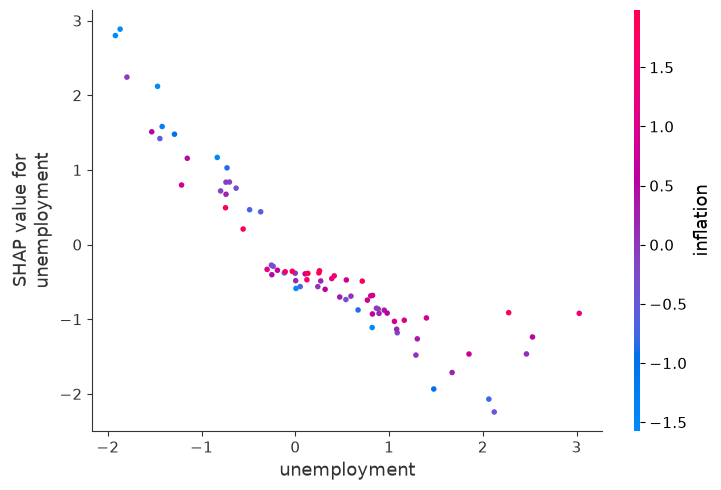

Correlation between unemployment and its SHAP value: -0.904
Average SHAP below median unemployment: 0.491
Average SHAP above median unemployment: -0.998


In [11]:
# Type the code here.
# Select the feature with the largest mean absolute SHAP value.
top_feature = importance.index[0]

# Find that feature&#x27;s column position in X.
top_idx = list(X.columns).index(top_feature)

# Dependence plot:
# x-axis = observed feature value
# y-axis = that feature&#x27;s SHAP contribution
# color = another feature chosen automatically to help reveal interaction
shap.dependence_plot(
    top_feature,
    sv.values,
    X_explain,
    interaction_index="auto",
    show=False
)
plt.tight_layout()
plt.show()

# Pull out the raw feature values and corresponding SHAP values.
feature_values = X_explain[top_feature]
feature_shap = sv.values[:, top_idx]

# Split observations into lower- and higher-value groups at the median.
median_value = feature_values.median()

# Simple numerical summary of the direction shown in the dependence plot.
print(
    "Correlation between unemployment and its SHAP value:",
    round(np.corrcoef(feature_values, feature_shap)[0, 1], 3)
)

print(
    "Average SHAP below median unemployment:",
    round(feature_shap[feature_values <= median_value].mean(), 3)
)

print(
    "Average SHAP above median unemployment:",
    round(feature_shap[feature_values > median_value].mean(), 3)
)

**How to read this result.** The dependence plot focuses on **unemployment**, the feature with the largest mean absolute SHAP value.

- The horizontal axis is the observed unemployment value.
- The vertical axis is unemployment's SHAP contribution.
- The **sign** tells us the direction:
  - a positive SHAP value means unemployment pushes the prediction upward;
  - a negative SHAP value means unemployment pushes the prediction downward.
- The **magnitude**, $|\text{SHAP}|$, tells us how large unemployment's contribution is.
  - values farther from zero mean a larger contribution;
  - values closer to zero mean a smaller contribution.

Here, the correlation between unemployment and its SHAP value is about $-0.904$.

Average unemployment SHAP is about

$$
+0.491
$$

for observations below the median unemployment value, and about

$$
-0.998
$$

for observations above the median unemployment value.

Thus, relatively low unemployment tends to push the fitted prediction upward, while relatively high unemployment tends to push the prediction downward.

Also,

$$
|-0.998|>|0.491|.
$$

So high unemployment has a **larger contribution in magnitude** on average.

In plain language:

> **As unemployment becomes higher, it tends to push the model's prediction downward more strongly.**

The color gradient can help show whether this pattern changes with another feature. The plot can also reveal nonlinear patterns that a single correlation number may miss.

These are patterns in the **fitted model**.

### Three plots, three questions

| Plot | Main question |
|---|---|
| Waterfall | Why did **this observation** get this prediction? |
| Beeswarm | Which features matter most **overall**, and do high values tend to push predictions up or down? |
| Dependence | How does one feature's contribution change as that feature's value changes? |

A SHAP value should always be read as an **average marginal contribution to the fitted prediction across possible feature-ordering contexts**.

## Exercise

1. Fit a random forest and compute SHAP values.
2. Identify the feature with the largest mean absolute SHAP value.
3. For observation $i=3$, verify

$$
\sum_j\phi_j(x_i)=\widehat f(x_i)-\phi_0.
$$

4. Draw a SHAP beeswarm plot. Interpret the horizontal position and gradient color, and explain what the plot suggests about one feature.

### Data

**What this code does.** Paste the instructor-supplied exercise DGP here. The full solution version generates the same predictors, outcome, and estimation/testing split.


In [12]:
# Paste the exercise DGP here.
rng_ex = np.random.default_rng(16)
n_ex = 300

X_ex = pd.DataFrame({
    "inflation": rng_ex.normal(size=n_ex),
    "unemployment": rng_ex.normal(size=n_ex),
    "interest_rate": rng_ex.normal(size=n_ex),
    "money_growth": rng_ex.normal(size=n_ex)
})

y_ex = (
    1.5
    + 1.1 * X_ex["inflation"]
    - 1.3 * X_ex["unemployment"]
    - 0.7 * X_ex["interest_rate"]
    + 0.4 * X_ex["money_growth"]
+ rng_ex.normal(scale=0.75, size=n_ex)
)

X_ex_train, X_ex_test, y_ex_train, y_ex_test = train_test_split(
    X_ex, y_ex, test_size=0.25, random_state=16
)

### Complete the exercise

**What this code does.** Fit the random forest, compute local and global SHAP values, check the prediction-gap identity, and draw the waterfall and beeswarm plots.


Most important feature: inflation
Prediction gap: -0.9580295739492649
Sum of SHAP values: -0.9580295838991878


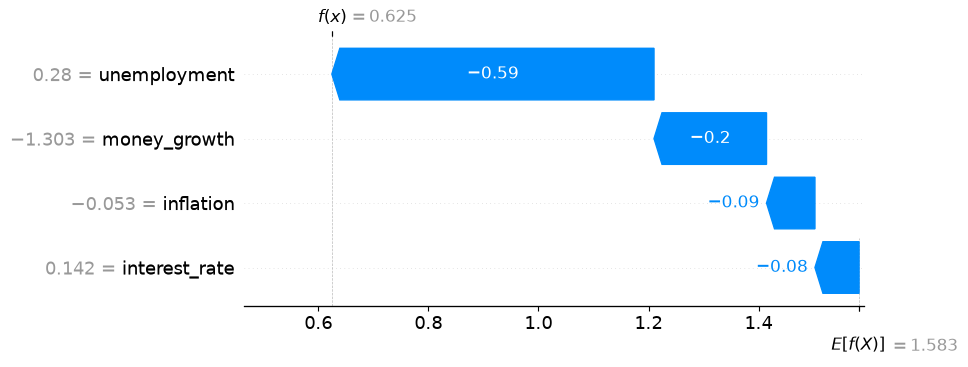

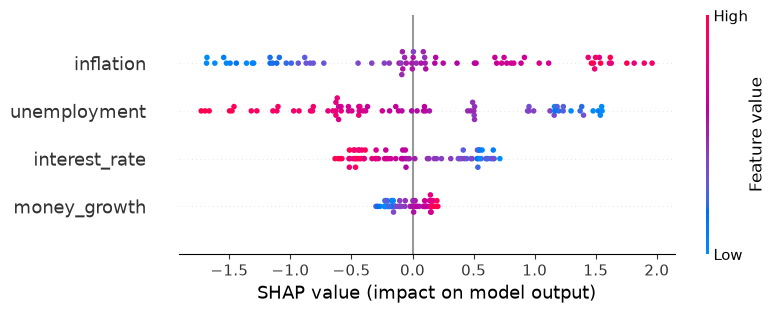

In [13]:
# Fit the random forest on the exercise estimation sample.
exercise_model = RandomForestRegressor(
    n_estimators=150,
    min_samples_leaf=5,
    random_state=16,
    n_jobs=-1
)

exercise_model.fit(X_ex_train, y_ex_train)              # Fit the model

# Background sample used to define the SHAP baseline.
background = X_ex_train.sample(50, random_state=16)

# Test observations to explain.
X_explain = X_ex_test.reset_index(drop=True)

# Build the SHAP explainer and compute SHAP values.
explainer = shap.Explainer(exercise_model, background)
sv_ex = explainer(X_explain)

# Global importance = mean absolute SHAP.
importance = pd.Series(
    np.abs(sv_ex.values).mean(axis=0),
    index=X_ex.columns
).sort_values(ascending=False)

# Explain the fourth test observation because Python starts counting at zero.
i = 3

phi0 = float(np.asarray(sv_ex[i].base_values).squeeze())  # Baseline
prediction = exercise_model.predict(X_explain.iloc[[i]])[0] # Fitted prediction
sum_phi = sv_ex[i].values.sum()                          # Sum of local SHAP values

print("Most important feature:", importance.index[0])
print("Prediction gap:", prediction - phi0)
print("Sum of SHAP values:", sum_phi)

# Local explanation for observation i = 3.
shap.plots.waterfall(sv_ex[i], show=False)
plt.show()

# Global view across all test observations.
shap.plots.beeswarm(sv_ex, show=False)
plt.show()


### Rubric and hints (10 points)

| Component | Points | Hint |
|---|---:|---|
| Fit model and compute SHAP | 3 | Use `.fit(...)` and `shap.Explainer(...)`. |
| Global importance | 2 | Average the **absolute** SHAP values across observations. |
| Prediction-gap identity | 3 | Compare `prediction - phi0` with `sum_phi`. |
| Plot and interpretation | 2 | Explain both **sign** (up/down) and **magnitude** (importance), and use the beeswarm color gradient to discuss high versus low feature values. |

Remember:

$$
\text{sign of SHAP}=\text{direction},
\qquad
|\text{SHAP}|=\text{size of contribution}.
$$
